Phase 1 — Shape, Types, and First Inspection

The first phase takes less than five minutes but gives you the structural skeleton of the dataset. 

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import missingno as msno

In [5]:
df = pd.read_csv("House Price Prediction Dataset.csv")


In [6]:
# Structure overview

print(df.head())
print(f'Shape: {df.shape}')
print(df.dtypes) 
print(df.tail())
print(df.sample(5, random_state=0))


   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  
Shape: (2000, 10)
Id            int64
Area          int64
Bedrooms      int64
Bathrooms     int64
Floors        int64
YearBuilt     int64
Location     object
Condition    object
Garage       object
Price         int64
dtype: object
        Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
1995  1996  4994         5          4       3       1923  Suburban       Poor   
1996  1997  3046         5         

In [36]:
# Missing Values

missing = df.isnull().sum()
missing_pct = 100 * missing / len(df)
missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct.round(2)
}).sort_values('missing_pct', ascending=False)
print(missing_report[missing_report.missing_count > 0])
print( missing)

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


In [38]:
# Duplicates

n_dupes = df.duplicated().sum()
print(n_dupes)
print(f'Duplicate rows: {n_dupes} ({100*n_dupes/len(df):.2f}%)')

0
Duplicate rows: 0 (0.00%)


In [9]:
# Numeric summary

print(df.describe().round(3))

             Id      Area  Bedrooms  Bathrooms    Floors  YearBuilt  \
count  2000.000  2000.000  2000.000   2000.000  2000.000   2000.000   
mean   1000.500  2786.210     3.004      2.552     1.994   1961.446   
std     577.495  1295.147     1.425      1.109     0.809     35.927   
min       1.000   501.000     1.000      1.000     1.000   1900.000   
25%     500.750  1653.000     2.000      2.000     1.000   1930.000   
50%    1000.500  2833.000     3.000      3.000     2.000   1961.000   
75%    1500.250  3887.500     4.000      4.000     3.000   1993.000   
max    2000.000  4999.000     5.000      4.000     3.000   2023.000   

            Price  
count    2000.000  
mean   537676.855  
std    276428.846  
min     50005.000  
25%    300098.000  
50%    539254.000  
75%    780086.000  
max    999656.000  


In [10]:
# Categorical Summary

cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f'{col}: {df[col].nunique()} unique | top: {df[col].value_counts().index[0]}')

Location: 4 unique | top: Downtown
Condition: 4 unique | top: Fair
Garage: 2 unique | top: No


Phase 2 — Univariate Analysis

The goal is to understand the distribution of every column:
where it is centred, how spread out it is, whether it is symmetric or skewed, and whether it contains extreme outliers.

In [43]:
plt.style.use('seaborn-v0_8-whitegrid')
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(num_cols)
print(cat_cols)

['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']
['Location', 'Condition', 'Garage']


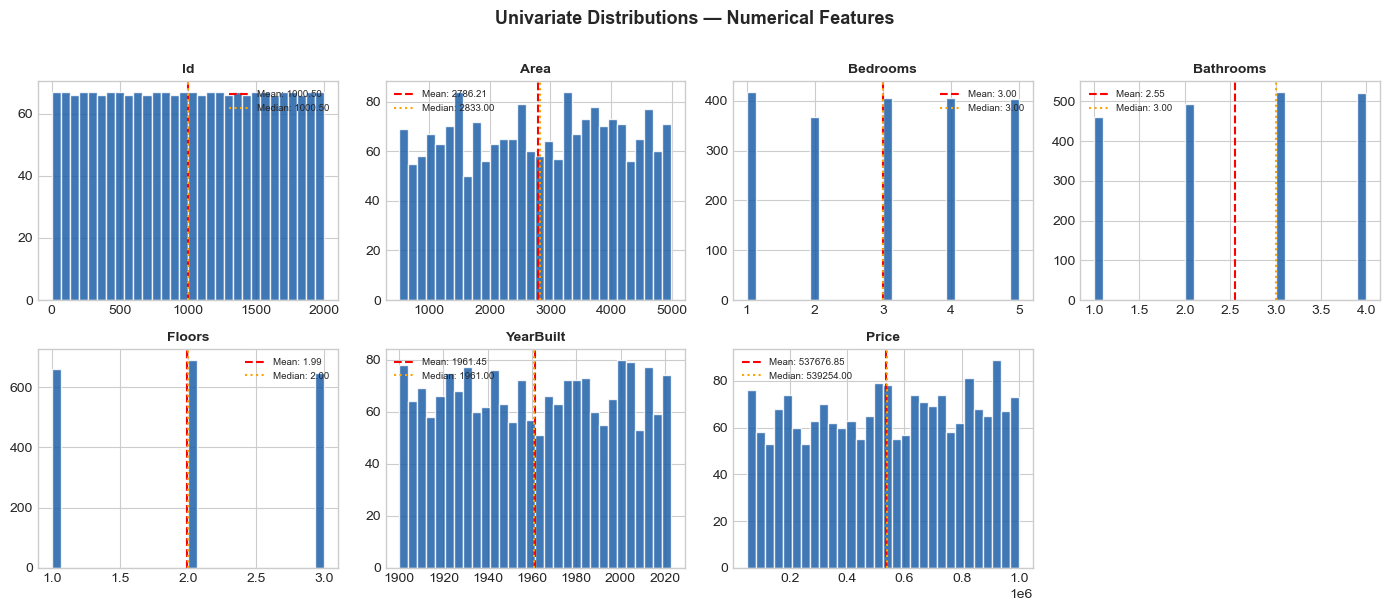

In [45]:
# NUMERICAL: Histogram grid

n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows*3))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#1E5FA8', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.2f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle=':', linewidth=1.5, label=f'Median: {df[col].median():.2f}')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)): # hide unused subplots
    axes[j].set_visible(False)
plt.suptitle('Univariate Distributions — Numerical Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("univariate_numerical.png",dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# NUMERICAL: Skewness table

skew = df[num_cols].skew().sort_values(ascending=False)
print('Highly skewed columns (|skew| > 1):', skew[skew.abs() > 1].index.tolist())

Highly skewed columns (|skew| > 1): []


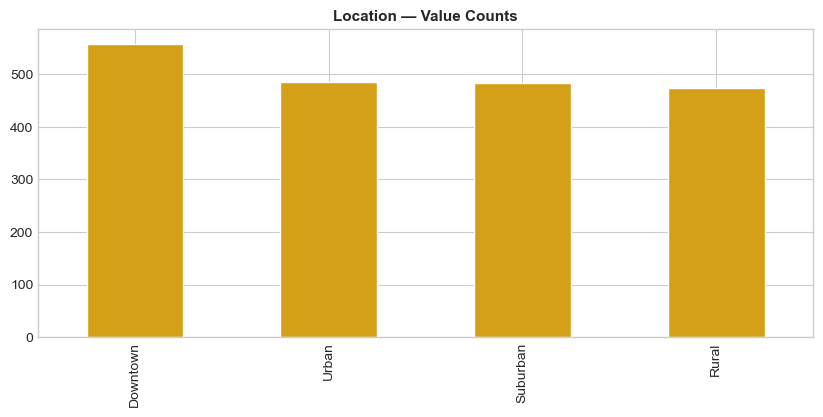

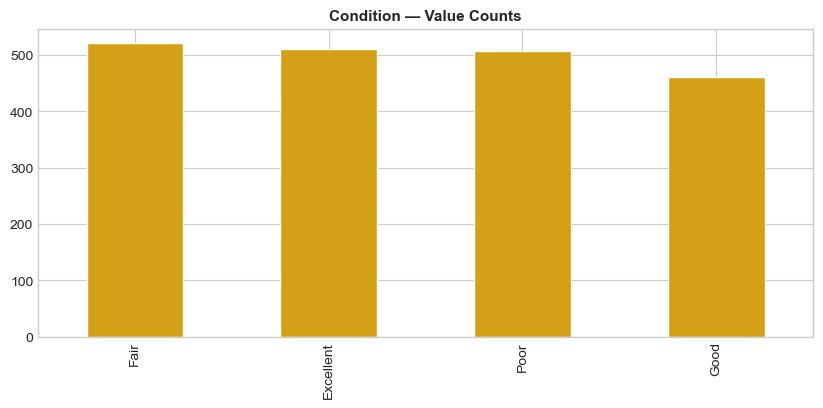

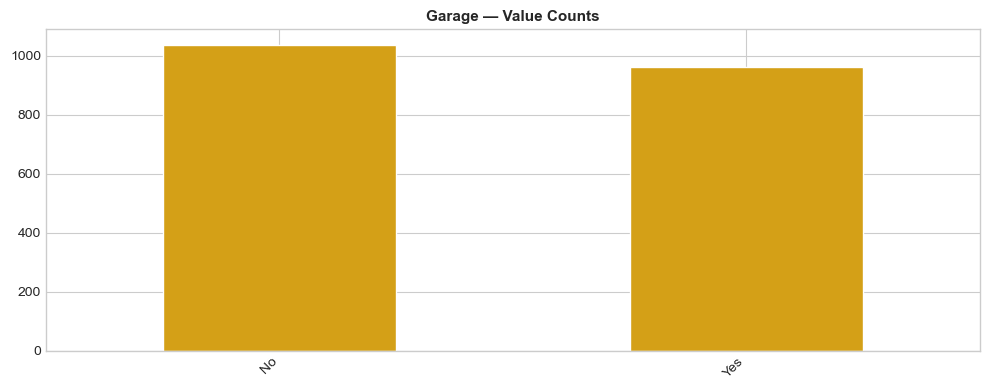

In [46]:
# CATEGORICAL: Bar charts

for col in cat_cols:
    counts = df[col].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, 4))
    counts.plot(kind='bar', ax=ax, color='#D4A017', edgecolor='white')
    ax.set_title(f'{col} — Value Counts', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'categorical_{col}.png', dpi=150)
plt.show()    

Phase 3 — Bivariate and Multivariate Analysis

Bivariate analysis examines how pairs of features relate to each other and how each feature relates to the target
variable. This is the phase where you discover which features will be useful for prediction and which are redundant or
uninformative.

In [19]:
TARGET = 'Price'

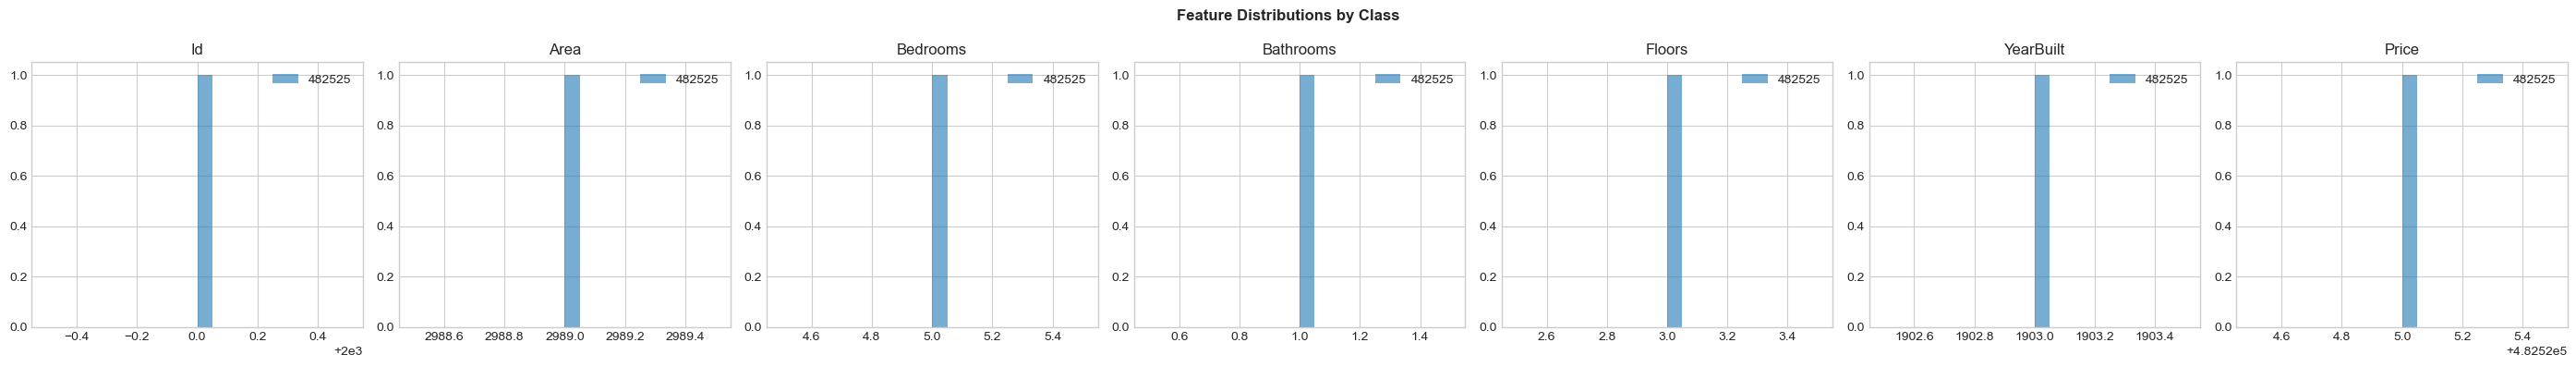

In [21]:
# NUMERICAL vs TARGET (classification)

fig, axes = plt.subplots(1, len(num_cols), figsize=(4*len(num_cols), 4))
for i, col in enumerate(num_cols):
    for label in df[TARGET].unique():
        subset = df[df[TARGET] == label][col].dropna()
    axes[i].hist(subset, bins=20, alpha=0.6, label=str(label))
    axes[i].set_title(col)
    axes[i].legend()    
plt.suptitle('Feature Distributions by Class', fontweight='bold')
plt.tight_layout()
plt.savefig('bivariate_target.png', dpi=150)
plt.show()    

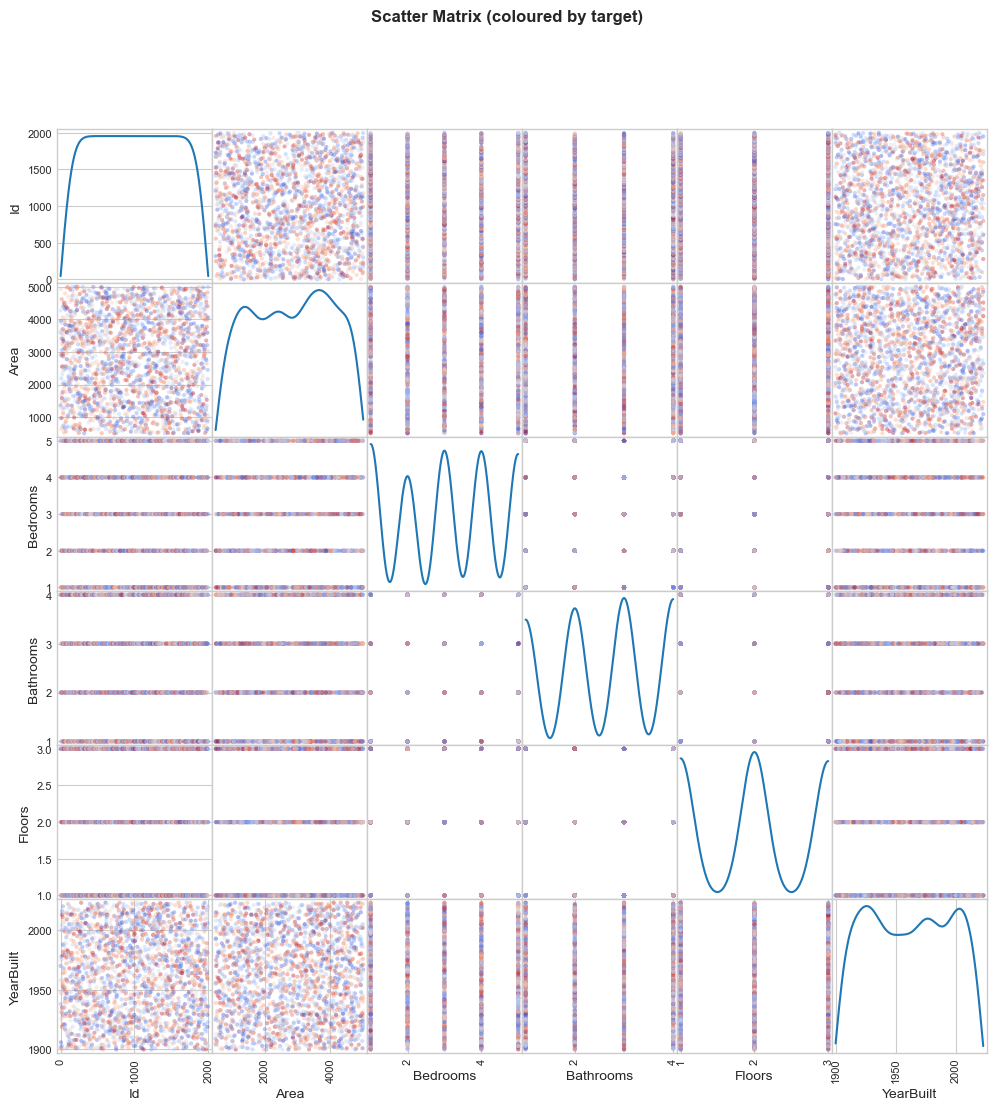

In [22]:
# SCATTER MATRIX 
# For regression: scatter each feature against the target
# For classification: colour-code by class

plot_cols = num_cols[:6] # limit to 6 for readability
pd.plotting.scatter_matrix(
    df[plot_cols],
    figsize=(12, 12), alpha=0.4, diagonal='kde',
    c=df[TARGET].astype('category').cat.codes,
    cmap='coolwarm'
)

plt.suptitle('Scatter Matrix (coloured by target)', fontweight='bold')
plt.savefig('scatter_matrix.png', dpi=150)
plt.show()

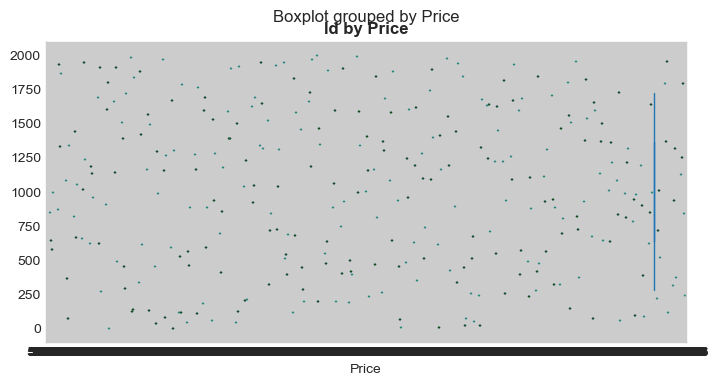

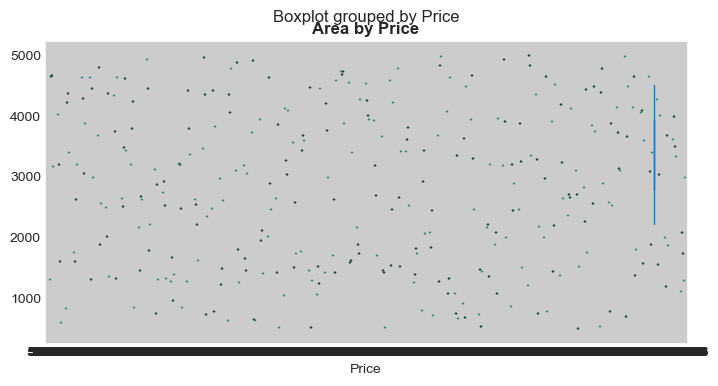

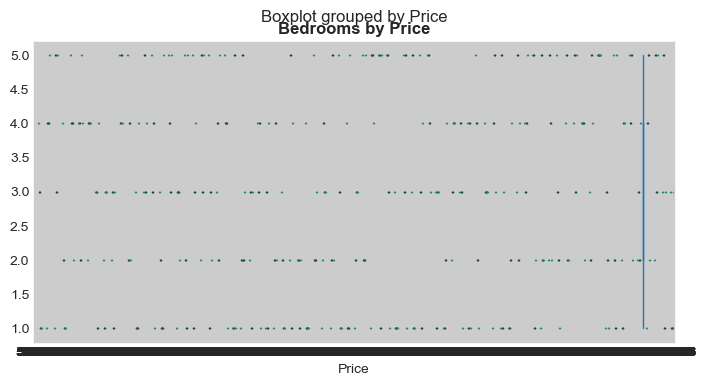

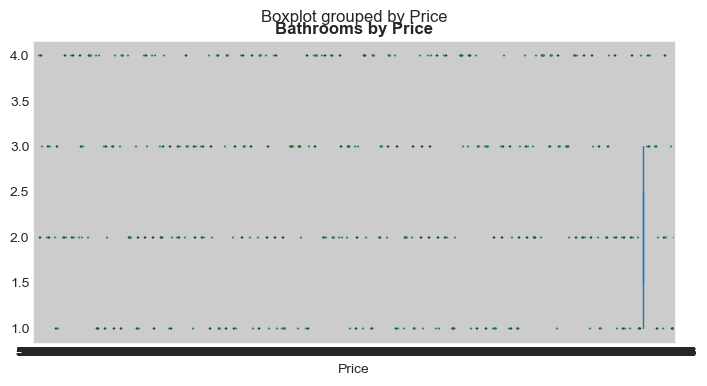

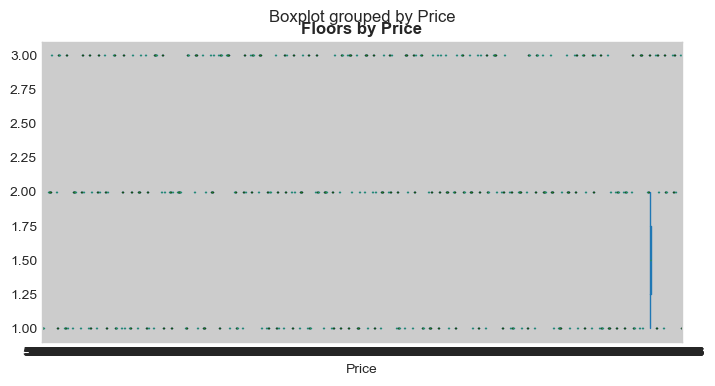

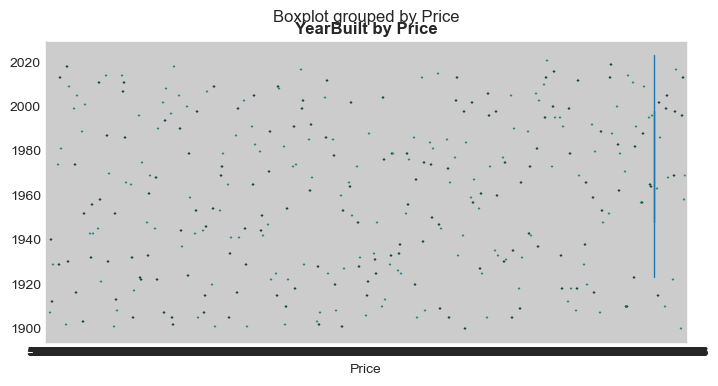

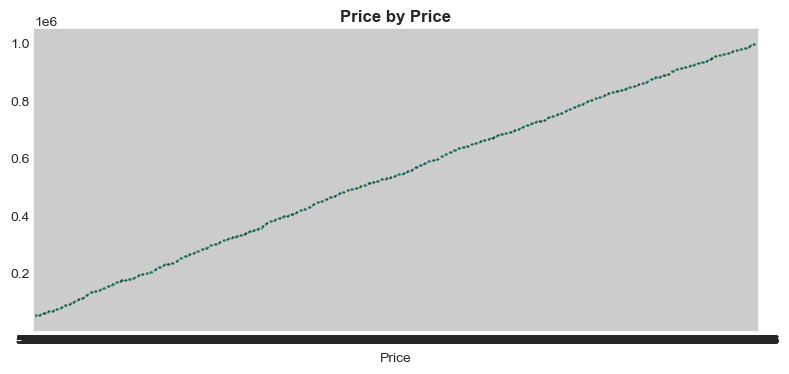

In [28]:
# GROUPED BOX PLOTS

for col in num_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    df.boxplot(column=col, by=TARGET, ax=ax)
    ax.set_title(f'{col} by {TARGET}', fontweight='bold')
plt.suptitle('')
plt.tight_layout()
plt.savefig('grouped_box.png', dpi=150)
plt.show()   

Phase 4: Missing Data Audit and Imputation

Checks how related missing values are

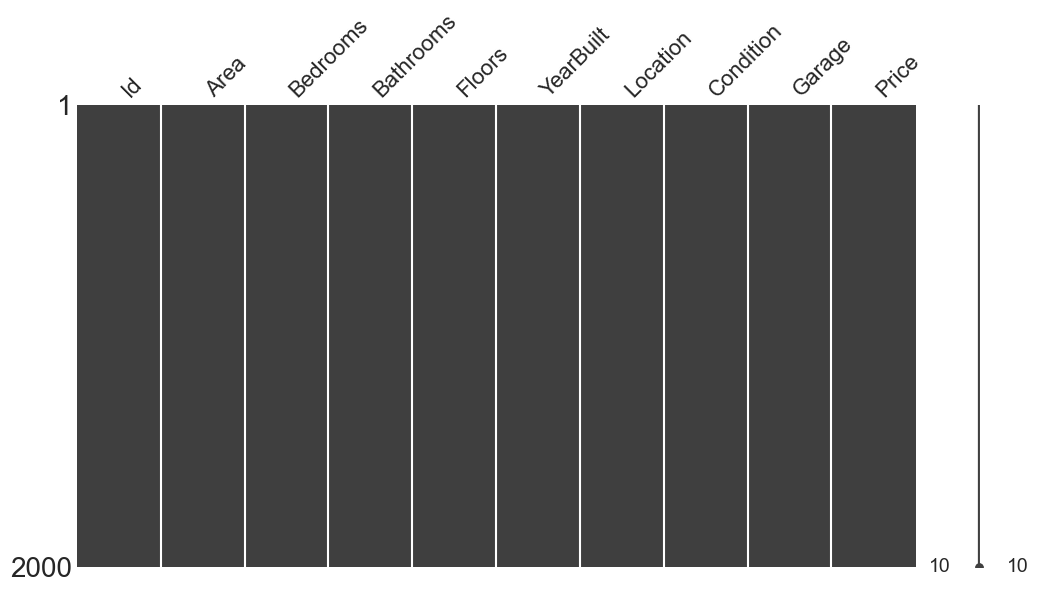

In [32]:
# VISUAL MISSING DATA MATRIX
# White streaks in columns = missing values. Patterns reveal structure.

msno.matrix(df, figsize=(12, 6))
plt.savefig('missing_matrix.png', dpi=150)
plt.show()

/Users/louisa/miniconda3/envs/aiLearning/lib/python3.13/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/Users/louisa/miniconda3/envs/aiLearning/lib/python3.13/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
Task was destroyed but it is pending!
task: <Task pending name='Task-528' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/louisa/miniconda3/envs/aiLearning/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-529' coro=<Kernel.shell_main() running at /Users/louisa/miniconda3/envs/aiLearning/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStr

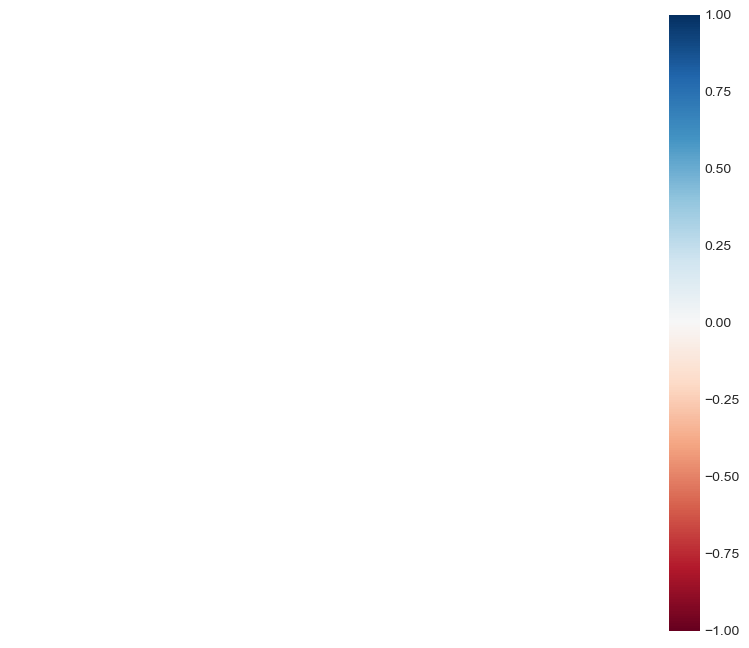

In [33]:
# HEATMAP OF MISSING CORRELATIONS
# Columns that tend to be missing together have high correlation

msno.heatmap(df, figsize=(10, 8))
plt.show()


Phase 5 — Outlier Detection



In [37]:
# Z-SCORE METHOD

from scipy import stats

z_scores = np.abs(stats.zscore(df[num_cols].dropna()))
outlier_mask = (z_scores > 3).any(axis=1)
print(f'Z-score outliers (|z|>3): {outlier_mask.sum()} rows')

Z-score outliers (|z|>3): 0 rows


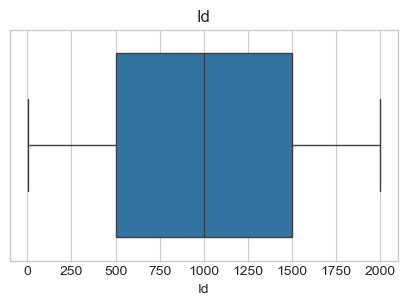

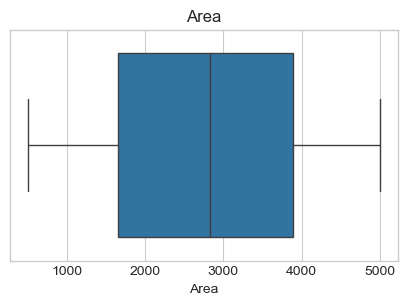

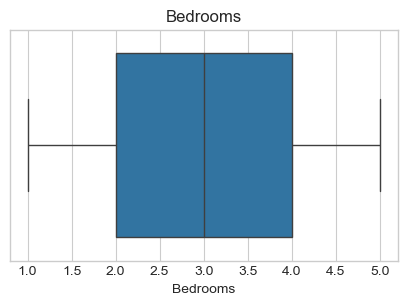

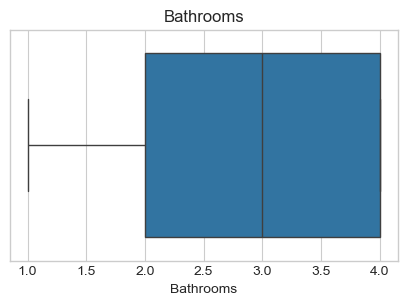

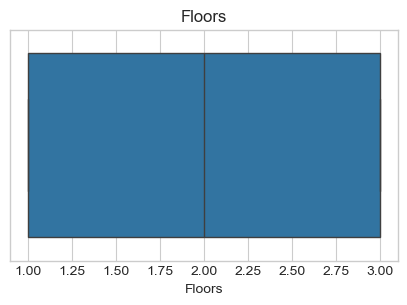

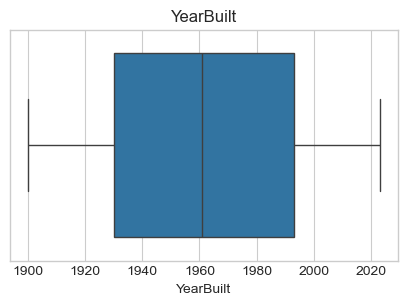

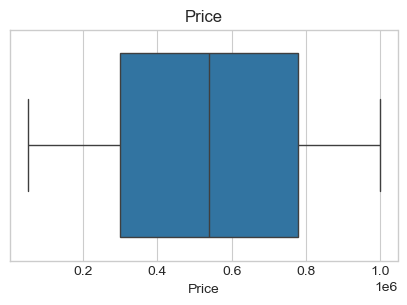

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()